In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font family: Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family: Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding top:120px;}
div.text_cell_render ul li {font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font color="red" size="6"> 01_머신러닝입문_Linear regression </font></b>
# 1. 기존 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erroerror ; 절대값평균)
-
https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
- https://www.mql5.com/ko/articles/11200

#### 섭씨 온도를 입력받아 화씨 온도로 출력(기존방식)

In [2]:
# 섭씨 온도를 입력받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [3]:
input_c = int(input('섭씨온도?'))
print('화씨온도는 ', celsius_to_faherenheit(input_c))

섭씨온도?1
화씨온도는  33.8


In [4]:
inputs = list(map(int, input('섭씨 온도 여러 개 입력 (공백으로 구분): ').split()))
for c in inputs:
    print(f'{c}℃ => 화씨온도는 {celsius_to_faherenheit(c)}℉')

섭씨 온도 여러 개 입력 (공백으로 구분): 1
1℃ => 화씨온도는 33.8℉


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    전체데이터셋에서 훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋으로 분할
3. 모델 구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)

```

## 2.1 노이즈가 없는 데이터로 실습

#### 1. 데이터 생성 및 import

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [7]:
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [8]:
# 출력 데이터
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

#### 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정

In [9]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립(입력)변수 :', scaled_data_C)
print('학습시 타겟(출력)변수 :', scaled_data_F)

학습시 독립(입력)변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟(출력)변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67 

#### 3. 모델 구성

In [10]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')
# GPU를 안쓰게 하려면 아래 코드 입력
# import os
# os.environ["CUDA_VISIVLE_DEVICES"] = "-1"

2.10.0


[]

#### --모델 생성 클래스 import
- from tensorflow.keras.models import Sequential # 모델 생성 클래스
- from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer츨 지정

In [11]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성 클래스
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer츨 지정

model = Sequential() #빈모델 생성
model.add(Dense(units=1, # 타겟(출력) 변수의 갯수
                input_shape=(1,) # 독립(입력)변수의 shape
               )) 
# .애드덴스출력1,인풋언더바쉐잎입력1
#model.add(Input(shape=(1,) )) # 입력층
#model.add(Dense(1) ) # 출력층

#### 4. 모델 학습과정 설정
- 옵티마이저 오솔길
- loss	손실 함수. 회귀 문제에서는 "mse" (Mean Squared Error), "mae" (Mean Absolute Error) 등
    - "mse" : 오차 제곱의 평균(이상치 영향이 확 올라감)
    - "mae" : 오차 절대값의 평균(이상치 영향이 감소)
- optimizer	가중치를 어떻게 업데이트할지 결정하는 알고리즘. adam, sgd, rmsprop 등이 대표적
    - "adam"	대부분의 상황에서 잘 동작함. 추천 기본값
    - "sgd"	Stochastic Gradient Descent. 단순하지만 느림
    - "rmsprop"	시계열/순환 모델에 잘 작동함
- metrics	학습 중 모니터링할 지표 (선택 사항). 예: "mae", "mape", "accuracy" (분류 문제용) 등

In [12]:
# 4. 모델 학습과정 설정
model.compile(loss="mse", # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용(오차계산법)
             optimizer="rmsprop", # 옵티마이저
             metrics=["mae"] #평가지표
             )
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


#### --학습전 예측 predict 반드시 2차원으로

In [13]:
# 학습전 예측
model.predict(np.array([[0],
                      [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 85ms/step


array([[ 0.        ],
       [-0.01498273]], dtype=float32)

#### --학습전 모델 저장(학습전 연습)

In [14]:
# 학습전 모델 저장(학습전이라 그냥 해봄)
model.save('model/before_learning.h5')

#### 5. 모델 학습시키기 - 1번만 실행

In [15]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(
    scaled_data_C, # 독립(입력)변수(훈련데이터)
    scaled_data_F, # 타겟(출력)변수(훈련데이터)
    epochs=1000,   # 학습횟수
    verbose=2, # 학습시 출력여부(0:학습내용출력X, 1대충 2자세히)
    #batch_size=32, # 32개씩 데이터를 잘라서 학습 -> 한번에 32개만 처리
    #validation_data=() # 학습 중간에 성능 평가할 검증 데이터
    )

Epoch 1/1000
4/4 - 0s - loss: 4.6992 - mae: 1.9480 - 397ms/epoch - 99ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.6536 - mae: 1.9372 - 6ms/epoch - 1ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.6192 - mae: 1.9292 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 4.5878 - mae: 1.9216 - 8ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 4.5604 - mae: 1.9151 - 8ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.5319 - mae: 1.9083 - 8ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.5062 - mae: 1.9022 - 8ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.4809 - mae: 1.8961 - 10ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.4565 - mae: 1.8902 - 9ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.4307 - mae: 1.8839 - 9ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.4090 - mae: 1.8786 - 9ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.3857 - mae: 1.8729 - 9ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 4.3605 - mae: 1.8668 - 8ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss:

Epoch 110/1000
4/4 - 0s - loss: 2.3780 - mae: 1.3072 - 11ms/epoch - 3ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.3613 - mae: 1.3019 - 10ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.3421 - mae: 1.2956 - 10ms/epoch - 3ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.3258 - mae: 1.2905 - 8ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.3110 - mae: 1.2857 - 7ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.2961 - mae: 1.2808 - 11ms/epoch - 3ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.2782 - mae: 1.2749 - 11ms/epoch - 3ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.2629 - mae: 1.2700 - 9ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.2460 - mae: 1.2646 - 8ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.2301 - mae: 1.2593 - 9ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 2.2147 - mae: 1.2543 - 9ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.1980 - mae: 1.2488 - 9ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 2.1820 - mae: 1.2435 - 9ms/epoch - 2ms/step
Epoch 1

Epoch 218/1000
4/4 - 0s - loss: 0.9657 - mae: 0.8025 - 9ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.9560 - mae: 0.7986 - 8ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.9464 - mae: 0.7946 - 7ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.9375 - mae: 0.7908 - 6ms/epoch - 1ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.9289 - mae: 0.7873 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.9200 - mae: 0.7836 - 8ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.9102 - mae: 0.7795 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.9018 - mae: 0.7761 - 8ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.8938 - mae: 0.7727 - 9ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.8862 - mae: 0.7696 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.8774 - mae: 0.7658 - 8ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.8677 - mae: 0.7616 - 9ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.8598 - mae: 0.7584 - 6ms/epoch - 2ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.3658 - mae: 0.5206 - 10ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.3637 - mae: 0.5193 - 7ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.3610 - mae: 0.5177 - 6ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.3582 - mae: 0.5159 - 8ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.3561 - mae: 0.5147 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.3548 - mae: 0.5137 - 8ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.3529 - mae: 0.5125 - 7ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.3510 - mae: 0.5112 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.3497 - mae: 0.5104 - 9ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.3476 - mae: 0.5090 - 6ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.3455 - mae: 0.5076 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.3436 - mae: 0.5063 - 6ms/epoch - 1ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.3425 - mae: 0.5056 - 9ms/epoch - 2ms/step
Epoch 339/1

Epoch 434/1000
4/4 - 0s - loss: 0.2400 - mae: 0.4232 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2391 - mae: 0.4223 - 7ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2382 - mae: 0.4216 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2370 - mae: 0.4205 - 7ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2359 - mae: 0.4197 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2351 - mae: 0.4190 - 7ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2341 - mae: 0.4181 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2332 - mae: 0.4172 - 7ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2324 - mae: 0.4164 - 6ms/epoch - 1ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2313 - mae: 0.4155 - 7ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2303 - mae: 0.4146 - 7ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2293 - mae: 0.4138 - 6ms/epoch - 1ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2283 - mae: 0.4128 - 7ms/epoch - 2ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1474 - mae: 0.3315 - 10ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1467 - mae: 0.3307 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1461 - mae: 0.3299 - 8ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1455 - mae: 0.3292 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1449 - mae: 0.3287 - 6ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1442 - mae: 0.3278 - 9ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1436 - mae: 0.3271 - 8ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1430 - mae: 0.3264 - 7ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1420 - mae: 0.3253 - 8ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1414 - mae: 0.3247 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1404 - mae: 0.3236 - 9ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1397 - mae: 0.3228 - 7ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1389 - mae: 0.3219 - 7ms/epoch - 2ms/step
Epoch 555/1

Epoch 650/1000
4/4 - 0s - loss: 0.0781 - mae: 0.2411 - 8ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0776 - mae: 0.2403 - 9ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0770 - mae: 0.2396 - 6ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0765 - mae: 0.2389 - 9ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0760 - mae: 0.2380 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0756 - mae: 0.2373 - 9ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0751 - mae: 0.2366 - 7ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0746 - mae: 0.2357 - 7ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0741 - mae: 0.2349 - 9ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0737 - mae: 0.2341 - 11ms/epoch - 3ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0732 - mae: 0.2334 - 9ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0728 - mae: 0.2327 - 6ms/epoch - 1ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0724 - mae: 0.2320 - 8ms/epoch - 2ms/step
Epoch 663/1

Epoch 758/1000
4/4 - 0s - loss: 0.0304 - mae: 0.1507 - 7ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0301 - mae: 0.1500 - 9ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0298 - mae: 0.1492 - 6ms/epoch - 1ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0295 - mae: 0.1484 - 7ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0291 - mae: 0.1475 - 8ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0288 - mae: 0.1466 - 7ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0285 - mae: 0.1458 - 8ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0283 - mae: 0.1452 - 10ms/epoch - 2ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0280 - mae: 0.1444 - 7ms/epoch - 2ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0277 - mae: 0.1438 - 6ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0274 - mae: 0.1429 - 9ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0270 - mae: 0.1419 - 11ms/epoch - 3ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0266 - mae: 0.1411 - 9ms/epoch - 2ms/step
Epoch 771/

Epoch 866/1000
4/4 - 0s - loss: 0.0053 - mae: 0.0623 - 6ms/epoch - 1ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0051 - mae: 0.0615 - 7ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0050 - mae: 0.0608 - 7ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0048 - mae: 0.0600 - 9ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0047 - mae: 0.0593 - 8ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0046 - mae: 0.0585 - 7ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0045 - mae: 0.0578 - 17ms/epoch - 4ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0043 - mae: 0.0569 - 7ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0042 - mae: 0.0560 - 8ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0041 - mae: 0.0552 - 9ms/epoch - 2ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0040 - mae: 0.0542 - 8ms/epoch - 2ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0038 - mae: 0.0533 - 8ms/epoch - 2ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0037 - mae: 0.0524 - 6ms/epoch - 2ms/step
Epoch 879/1

Epoch 970/1000
4/4 - 0s - loss: 5.2539e-07 - mae: 6.9977e-04 - 10ms/epoch - 2ms/step
Epoch 971/1000
4/4 - 0s - loss: 1.8623e-07 - mae: 4.2138e-04 - 12ms/epoch - 3ms/step
Epoch 972/1000
4/4 - 0s - loss: 5.7329e-08 - mae: 2.2376e-04 - 11ms/epoch - 3ms/step
Epoch 973/1000
4/4 - 0s - loss: 4.8320e-07 - mae: 6.1234e-04 - 9ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 1.4353e-06 - mae: 0.0011 - 15ms/epoch - 4ms/step
Epoch 975/1000
4/4 - 0s - loss: 4.5425e-08 - mae: 1.9589e-04 - 15ms/epoch - 4ms/step
Epoch 976/1000
4/4 - 0s - loss: 6.2301e-08 - mae: 2.3220e-04 - 12ms/epoch - 3ms/step
Epoch 977/1000
4/4 - 0s - loss: 1.6257e-06 - mae: 0.0012 - 27ms/epoch - 7ms/step
Epoch 978/1000
4/4 - 0s - loss: 5.1830e-08 - mae: 2.1902e-04 - 11ms/epoch - 3ms/step
Epoch 979/1000
4/4 - 0s - loss: 1.5549e-08 - mae: 1.0911e-04 - 8ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 8.0480e-07 - mae: 8.1262e-04 - 8ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 1.4715e-06 - mae: 0.0011 - 12ms/epoch - 3ms/

#### 6. 모델 평가하기(그래프를 통해 loss와 metrics값의 추이, 평가함수)

In [18]:
# 6. 모델 평가하기(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[4.699224472045898, 4.653608798980713, 4.619197845458984, 4.587825298309326, 4.560433864593506]
[1.9479609727859497, 1.9371684789657593, 1.929168701171875, 1.9216476678848267, 1.9150723218917847]


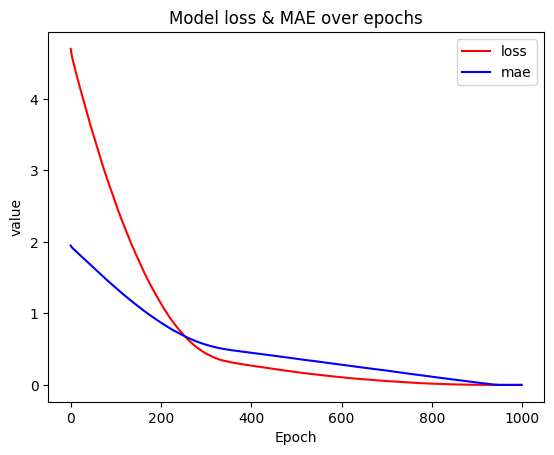

In [22]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 label 추가
plt.xlabel('Epoch') #학습횟수
plt.ylabel('value') #오차값
plt.title('Model loss & MAE over epochs')
plt.show()

#### 7. 모델 저장 및 사용(predict, save 반드시 2차원넘파이배열)

In [24]:
# 7. 모델 저장 및 사용
# 학습후 예측
model.predict(np.array([[0],
                      [0.01]])) # 섭씨온도 0, 1도는 화씨공ㄴ도 몇도?

1/1 [==============================] - 0s 32ms/step


array([[0.32058108],
       [0.3385887 ]], dtype=float32)

In [25]:
model.save('model/after_learning.h5')

#### --실제값그래프

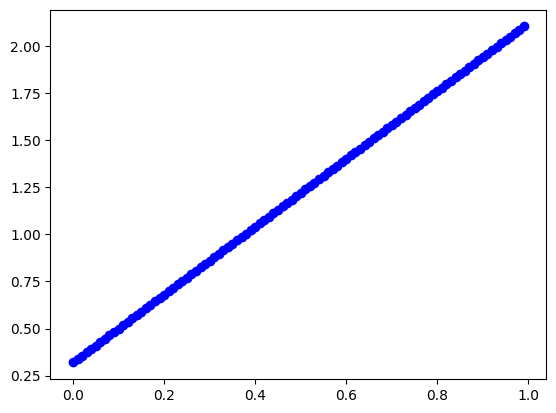

In [27]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

#### --예측값 그래프

In [30]:
# 예측값 그래프
y_hat = model.predict([scaled_data_C])
#h_hat

for h, y in zip(y_hat, scaled_data_F):
    print('예측값:{}, 실제값:{}, 오차:{}'.format(h,
                                        y,
                                        h[0]-y))

4/4 [==============================] - 0s 2ms/step
예측값:[0.32058108], 실제값:0.32, 오차:0.0005810785293579035
예측값:[0.3385887], 실제값:0.33799999999999997, 오차:0.0005887145996094079
예측값:[0.35659635], 실제값:0.35600000000000004, 오차:0.0005963506698608012
예측값:[0.374604], 실제값:0.374, 오차:0.0006039867401123056
예측값:[0.39261162], 실제값:0.392, 오차:0.0006116228103637544
예측값:[0.41061926], 실제값:0.41, 오차:0.0006192588806152588
예측값:[0.4286269], 실제값:0.428, 오차:0.0006268949508667077
예측값:[0.44663453], 실제값:0.446, 오차:0.0006345310211181565
예측값:[0.46464217], 실제값:0.46399999999999997, 오차:0.0006421670913696609
예측값:[0.48264983], 실제값:0.48200000000000004, 오차:0.0006498329639434419
예측값:[0.50065744], 실제값:0.5, 오차:0.0006574392318725586
예측값:[0.5186651], 실제값:0.518, 오차:0.0006650753021240075
예측값:[0.5366727], 실제값:0.536, 오차:0.0006727113723754563
예측값:[0.55468035], 실제값:0.554, 오차:0.0006803474426269052
예측값:[0.572688], 실제값:0.5720000000000001, 오차:0.000687983512878354
예측값:[0.5906957], 실제값:0.59, 오차:0.0006956791877746893
예측값:[0.60870326], 실제값:0.608, 오차

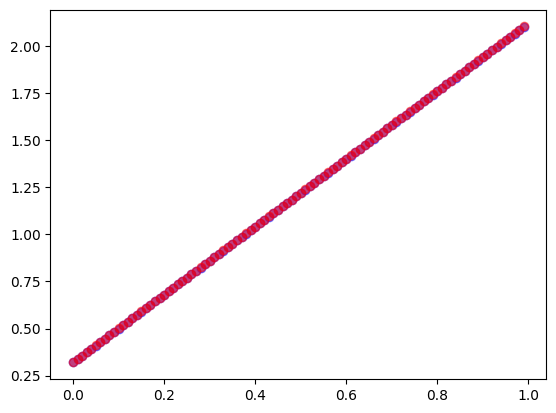

In [31]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5) # 투명한 점그래프
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)

## 2.2 노이즈가 있는 데이터로 실습

#### 2-2 1,2 데이터 생성 및 전처리

In [33]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균0, 표준편차 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F + noise

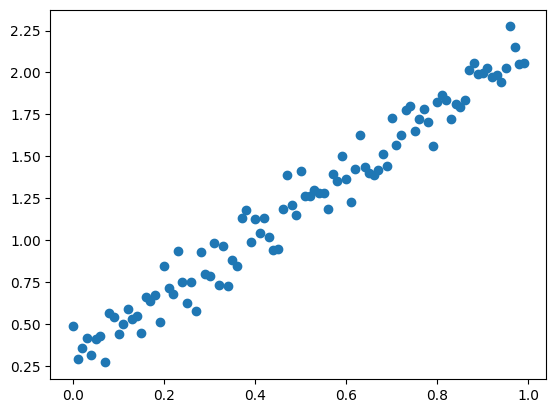

In [34]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

#### 2-2 3,4 모델구성 학습과정설정

In [35]:
# 3. 모델 구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))

# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


#### 2-2 5 모델학습

In [36]:
# 5.모델 학습시키기
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F,
                  epochs=1000,
                  verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.2816 - mae: 1.3715
Epoch 2/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.2469 - mae: 1.3598
Epoch 3/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.2233 - mae: 1.3516
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.2033 - mae: 1.3448
Epoch 5/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.1834 - mae: 1.3380
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.1673 - mae: 1.3325
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.1503 - mae: 1.3267
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.1318 - mae: 1.3203
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.1142 - mae: 1.3141
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.0970 - mae: 1.3081
Epoch 11/1000
4/4 [==============================] - 0s 4ms/step - lo

4/4 [==============================] - 0s 3ms/step - loss: 0.3336 - mae: 0.4713
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3286 - mae: 0.4682
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3231 - mae: 0.4647
Epoch 177/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3181 - mae: 0.4616
Epoch 178/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3143 - mae: 0.4591
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3090 - mae: 0.4559
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3049 - mae: 0.4530
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2999 - mae: 0.4498
Epoch 182/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.2954 - mae: 0.4467
Epoch 183/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.2909 - mae: 0.4438
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0811 - mae: 0.2396
Epoch 347/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0806 - mae: 0.2388
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0800 - mae: 0.2379
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0795 - mae: 0.2371
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0791 - mae: 0.2365
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0786 - mae: 0.2357
Epoch 352/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0781 - mae: 0.2349
Epoch 353/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0777 - mae: 0.2342
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0774 - mae: 0.2337
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0770 - mae: 0.2331
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0226 - mae: 0.1236
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0225 - mae: 0.1232
Epoch 520/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0222 - mae: 0.1227
Epoch 521/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0221 - mae: 0.1222
Epoch 522/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0219 - mae: 0.1216
Epoch 523/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0217 - mae: 0.1214
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0215 - mae: 0.1206
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0214 - mae: 0.1202
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0212 - mae: 0.1196
Epoch 527/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0210 - mae: 0.1190
Epoch 528/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0106 - mae: 0.0804
Epoch 691/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0105 - mae: 0.0803
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0803
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0804
Epoch 694/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0105 - mae: 0.0806
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0807
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0805
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0809
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0810
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0105 - mae: 0.0812
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

#### 6. 학습된 모델 과정 살펴보기

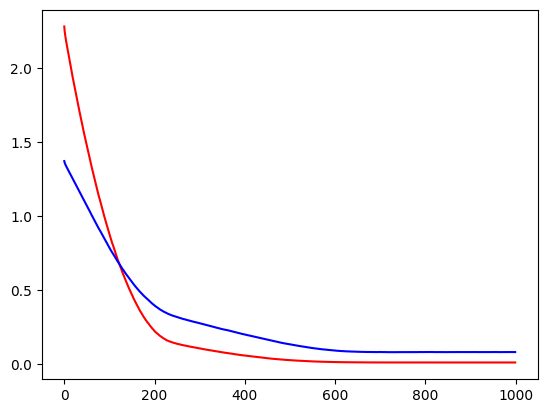

In [39]:
# 6. 학습된 모델 과정 살펴보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')
plt.show()

In [45]:
model2.save('model/noise_after_learning.h5')

In [46]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 2ms/step


In [47]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print('실제값:{}, 예측값:{}, 오차:{}'.format(y, #실측값
                                        h, #예측값
                                        h[0]-y
                                        ))

실제값:0.48905257038003563, 예측값:[0.30254552], 오차:-0.18650705269700646
실제값:0.2914062629459167, 예측값:[0.3208934], 오차:0.02948714392206425
실제값:0.3592820163678585, 예측값:[0.33924127], 오차:-0.02004075011724815
실제값:0.4147516282996508, 예측값:[0.35758916], 오차:-0.057162472864088654
실제값:0.31310769713742614, 예측값:[0.375937], 오차:0.06282931768076538
실제값:0.4102065572905948, 예측값:[0.3942849], 오차:-0.015921653287451487
실제값:0.42791096141420687, 예측값:[0.41263276], 오차:-0.015278198028434165
실제값:0.2705275693654579, 예측값:[0.43098065], 오차:0.16045308320526658
실제값:0.5657658005663493, 예측값:[0.44932854], 오차:-0.11643725881067302
실제값:0.542049851591955, 예측값:[0.4676764], 오차:-0.07437345045364929
실제값:0.43745710260332404, 예측값:[0.4860243], 오차:0.0485671877199334
실제값:0.5008451738804279, 예측값:[0.5043722], 오차:0.003527005627781299
실제값:0.5865299374196752, 예측값:[0.52272004], 오차:-0.06380989852883656
실제값:0.5278643584808353, 예측값:[0.5410679], 오차:0.013203539792632668
실제값:0.5477250921327455, 예측값:[0.5594158], 오차:0.011690725127996737
실제값:0.444675858750

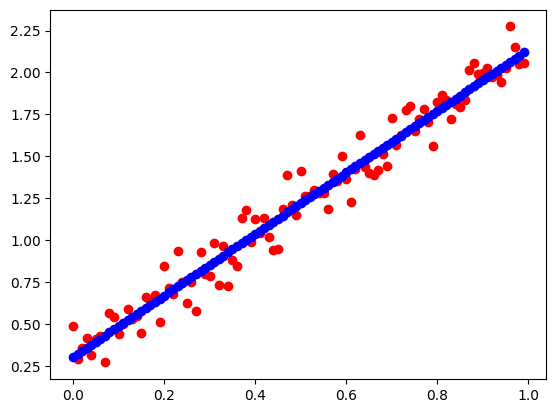

In [48]:
plt.scatter(x=scaled_data_C,
           y=noised_scaled_data_F,
           c='r')
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b')